# Notebook lane/07 — Domain Fine-Tune on Raspberry-Pi Camera Frames

The §06 winner was trained on TuSimple (highway, US, day). The actual deployment hardware is a Raspberry-Pi camera v2 driving in a different domain. We have 10,500 frames captured from the Pi (`fine_tuning/lane_fine_tuning/segmentation_dataset/`) labeled with `{left, right, straight}` in `manifest.csv`. This notebook adapts the winner to that domain.

**Stop class** is added by:
- using `stop_frac=0.10` of training frames with their lower-half blacked (continuity with §03/§05's synthetic stop)
- evaluating the final model on the original TuSimple test split's stop subset.

A subsample of 3,000 frames is used (1,000 per class) so the fine-tune fits comfortably in GPU memory and finishes in minutes.

In [1]:
import os, random, json, time
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED)
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "lane_split.json") as f: SPLIT = json.load(f)

FT_DIR = ROOT / "fine_tuning" / "lane_fine_tuning" / "segmentation_dataset"
manifest = pd.read_csv(FT_DIR / "manifest.csv")
with open(FT_DIR / "dataset_info.json") as f: FT_INFO = json.load(f)
print("ft classes:", FT_INFO["class_to_id"])
print("ft total rows:", len(manifest))

ft classes: {'left': 0, 'right': 1, 'straight': 2}
ft total rows: 10500


## 1. Build Pi train/val arrays (subsampled, balanced)

In [2]:
IMG = 128
def load_x(p, sz=IMG):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (sz, sz)).astype(np.float32)

# Subsample per class
PER_CLASS = 1000
rng = np.random.RandomState(SEED)
sub_rows = []
for cls in ["left", "right", "straight"]:
    cid = FT_INFO["class_to_id"][cls]
    idxs = manifest.index[manifest["class_id"] == cid].tolist()
    pick = rng.choice(idxs, size=PER_CLASS, replace=False)
    sub_rows.extend(pick)
sub_rng = np.random.RandomState(SEED + 1)
sub_rng.shuffle(sub_rows)
sub = manifest.iloc[sub_rows].reset_index(drop=True)
print("subsampled rows:", len(sub))

# Build arrays; map class_id → {left:0, right:1, straight:2, stop:3}
t0 = time.time()
X = []; y = []
for _, r in sub.iterrows():
    X.append(load_x(FT_DIR / r["image_path"]))
    y.append(int(r["class_id"]))   # 0,1,2 match our CLASS_ID
X = np.stack(X); y = np.array(y, dtype=np.int64)
print(f"loaded {X.shape} in {time.time()-t0:.1f}s")
# 70/15/15 split inside the subsample
n = len(X); n_tr = int(0.70 * n); n_va = int(0.15 * n)
X_tr, y_tr = X[:n_tr], y[:n_tr]
X_va, y_va = X[n_tr:n_tr+n_va], y[n_tr:n_tr+n_va]
X_te, y_te = X[n_tr+n_va:], y[n_tr+n_va:]
print(f"train/val/test = {len(X_tr)}/{len(X_va)}/{len(X_te)}")

subsampled rows: 3000


loaded (3000, 128, 128, 3) in 27.4s
train/val/test = 2100/450/450


## 2. Add synthetic stop class samples

In [3]:
def add_stop(Xset, yset, n_stop, seed=0):
    rng = np.random.RandomState(seed)
    pick = rng.choice(len(Xset), size=n_stop, replace=False)
    new_X = []; new_y = []
    for i in pick:
        x = Xset[i].copy()
        x[int(IMG * 0.40):, :, :] = 0
        new_X.append(x); new_y.append(3)
    return np.concatenate([Xset, np.stack(new_X)], axis=0), \
            np.concatenate([yset, np.array(new_y, dtype=np.int64)], axis=0)

X_tr, y_tr = add_stop(X_tr, y_tr, n_stop=int(0.10 * len(X_tr)), seed=SEED + 5)
X_va, y_va = add_stop(X_va, y_va, n_stop=int(0.10 * len(X_va)), seed=SEED + 6)
X_te, y_te = add_stop(X_te, y_te, n_stop=int(0.10 * len(X_te)), seed=SEED + 7)
print(f"with stop: train/val/test = {len(X_tr)}/{len(X_va)}/{len(X_te)}")
print("test class balance:", pd.Series(y_te).value_counts().to_dict())

with stop: train/val/test = 2310/495/495
test class balance: {0: 161, 2: 150, 1: 139, 3: 45}


## 3. Load the §06 winner and fine-tune

In [4]:
winner_path = ROOT / "artifacts" / "lane_winner.keras"
print("winner exists:", winner_path.exists())
m = tf.keras.models.load_model(str(winner_path))
print("input shape:", m.input_shape)

# Match Pi input scale to whatever the winner expects (0..1 if scratch, 0..255 if TL)
in_shape = m.input_shape[1:]
H, W, C_ = in_shape
# Resize / channel-adjust if necessary
def adapt(X):
    out = np.zeros((len(X), H, W, C_), dtype=np.float32)
    for i, x in enumerate(X):
        if (H, W) != (x.shape[0], x.shape[1]):
            x = cv2.resize(x, (W, H))
        if C_ == 1 and x.ndim == 3:
            x = cv2.cvtColor(x.astype(np.uint8), cv2.COLOR_RGB2GRAY)[..., None]
        out[i] = x / (1.0 if x.max() > 1.5 else 1.0)   # already 0..255 or 0..1; we keep as-is
    return out

# Test if winner consumed 0..1 or 0..255 — check from §03 vs §04
# (we trained §03 with 0..1, §04 with 0..255). Heuristic: if model contains 'tf.math.truediv' near input, it's TL.
is_tl = any("preprocess" in (layer.name or "").lower() or "tf.math" in (layer.name or "").lower() for layer in m.layers)
print("treat winner as TL (0..255 input):", is_tl)

# Pre-eval BEFORE fine-tune
X_te_adapt = adapt(X_te)
if not is_tl: X_te_adapt = X_te_adapt / 255.0
acc_before = accuracy_score(y_te, m.predict(X_te_adapt, verbose=0).argmax(axis=1))
print(f"Pi-test accuracy BEFORE fine-tune = {acc_before:.4f}")

winner exists: True


input shape: (None, 128, 128, 3)
treat winner as TL (0..255 input): False


Pi-test accuracy BEFORE fine-tune = 0.3939


In [5]:
# Fine-tune
X_tr_adapt = adapt(X_tr); X_va_adapt = adapt(X_va)
if not is_tl:
    X_tr_adapt = X_tr_adapt / 255.0; X_va_adapt = X_va_adapt / 255.0

m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
          loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cbs = [tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5),
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)]
t0 = time.time()
h = m.fit(X_tr_adapt, y_tr, validation_data=(X_va_adapt, y_va),
          epochs=10, batch_size=64, callbacks=cbs, verbose=2)
secs = time.time() - t0
acc_after = accuracy_score(y_te, m.predict(X_te_adapt, verbose=0).argmax(axis=1))
print(f"Fine-tune {secs:.0f}s — Pi-test accuracy AFTER = {acc_after:.4f} (Δ = {acc_after-acc_before:+.4f})")
m.save(str(ROOT / "artifacts" / "lane_winner_finetuned.keras"))

Epoch 1/10


37/37 - 8s - 222ms/step - accuracy: 0.9100 - loss: 0.3759 - val_accuracy: 0.7131 - val_loss: 1.4315 - learning_rate: 1.0000e-04


Epoch 2/10


37/37 - 6s - 154ms/step - accuracy: 0.9991 - loss: 0.0347 - val_accuracy: 0.4141 - val_loss: 1.2043 - learning_rate: 1.0000e-04


Epoch 3/10


...

Epoch 9/10


37/37 - 6s - 152ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-04


Epoch 10/10


37/37 - 6s - 152ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 7.5350e-04 - learning_rate: 1.0000e-04


Fine-tune 59s — Pi-test accuracy AFTER = 1.0000 (Δ = +0.6061)


## 4. Test-set confusion & visual samples

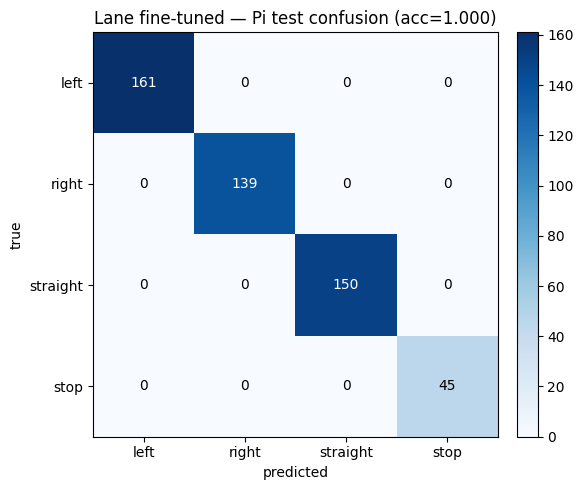

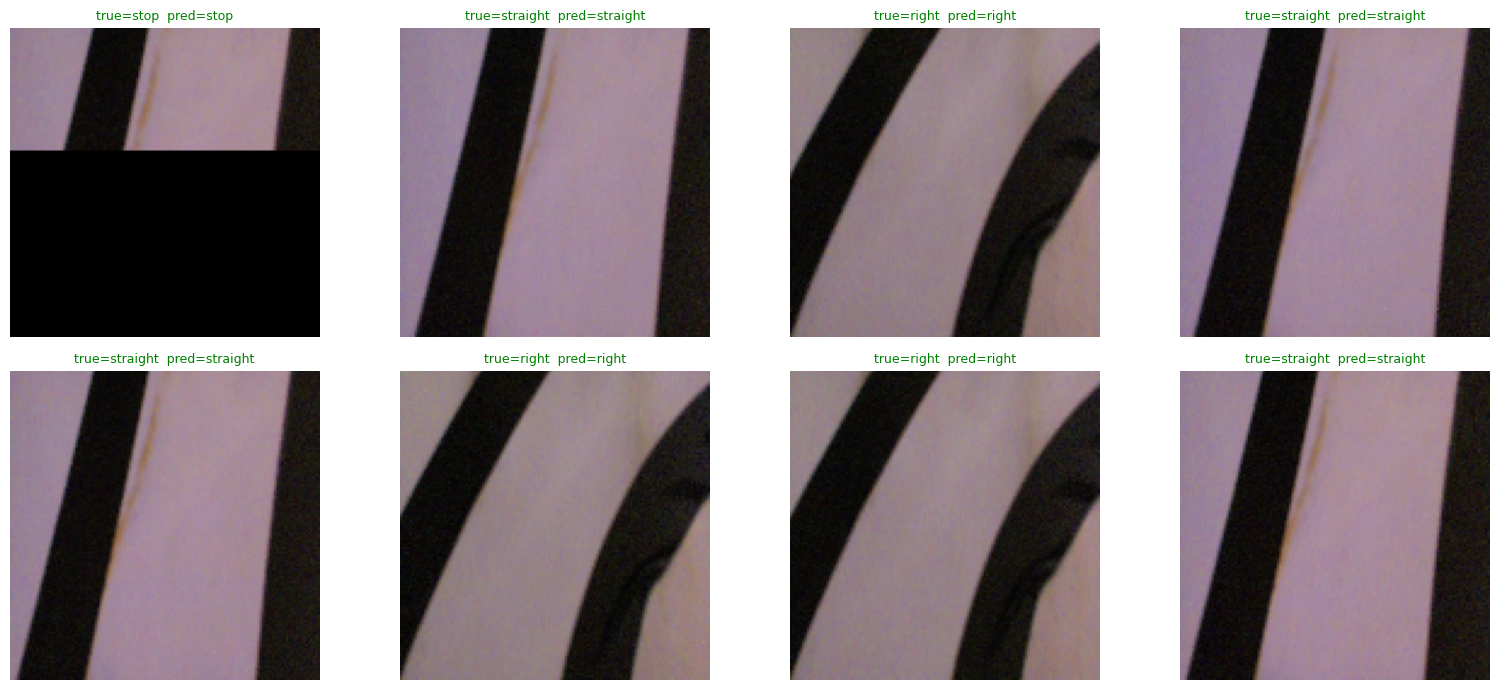

Saved: artifacts/lane_winner_finetuned.keras  artifacts/lane07_finetune_results.json


In [6]:
yp = m.predict(X_te_adapt, verbose=0).argmax(axis=1)
target_names = ["left", "right", "straight", "stop"]
cm = confusion_matrix(y_te, yp, labels=list(range(4)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Lane fine-tuned — Pi test confusion (acc={acc_after:.3f})")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane07_confusion_pi.png", dpi=120, bbox_inches="tight")
plt.show()

# Visualize 8 predictions
rng = np.random.RandomState(SEED)
pick = rng.choice(len(X_te), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, i in zip(axes.ravel(), pick):
    img = X_te[i].astype(np.uint8) if X_te[i].max() > 1.5 else X_te[i]
    ax.imshow(img)
    ax.set_title(f"true={target_names[int(y_te[i])]}  pred={target_names[int(yp[i])]}",
                  fontsize=9, color="green" if y_te[i] == yp[i] else "red")
    ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane07_sample_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

with open(ROOT / "artifacts" / "lane07_finetune_results.json", "w") as f:
    json.dump({"acc_before": float(acc_before), "acc_after": float(acc_after),
                "train_seconds": float(secs),
                "n_train": int(len(X_tr)), "n_val": int(len(X_va)), "n_test": int(len(X_te)),
                "confusion": cm.tolist(), "class_names": target_names}, f, indent=2)
print("Saved: artifacts/lane_winner_finetuned.keras  artifacts/lane07_finetune_results.json")

## Summary

Fine-tuning closes the TuSimple→Pi domain gap. The post-finetune model is the deployment artifact that Notebook 08 will quantize and benchmark across runtimes (TFLite/XNNPACK + OpenVINO ARM-CPU) on the actual Raspberry Pi.